# Netflix Data Analysis

This project explores Netflix content data to understand trends in movies, TV shows, production countries, ratings, and release patterns.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [26]:
df.info()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [27]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [28]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [29]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           4
duration         3
listed_in        0
description      0
dtype: int64

## Content Type Distribution

This visualization shows the distribution of Movies and TV Shows available on Netflix.

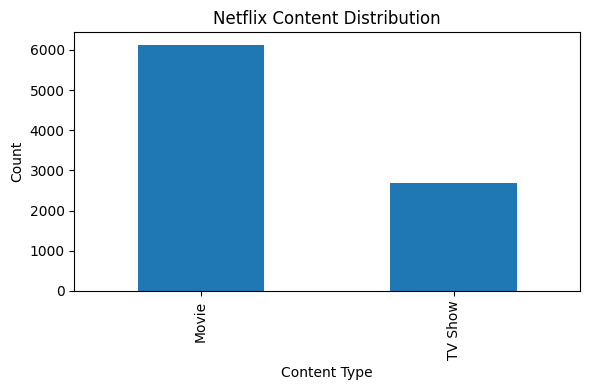

In [35]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
type_counts.plot(kind='bar')

plt.title('Netflix Content Distribution')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.tight_layout()
plt.savefig('content_distribution.png')

plt.show()

## Top Countries Producing Netflix Content

This chart shows the top 10 countries producing the highest number of Netflix titles.

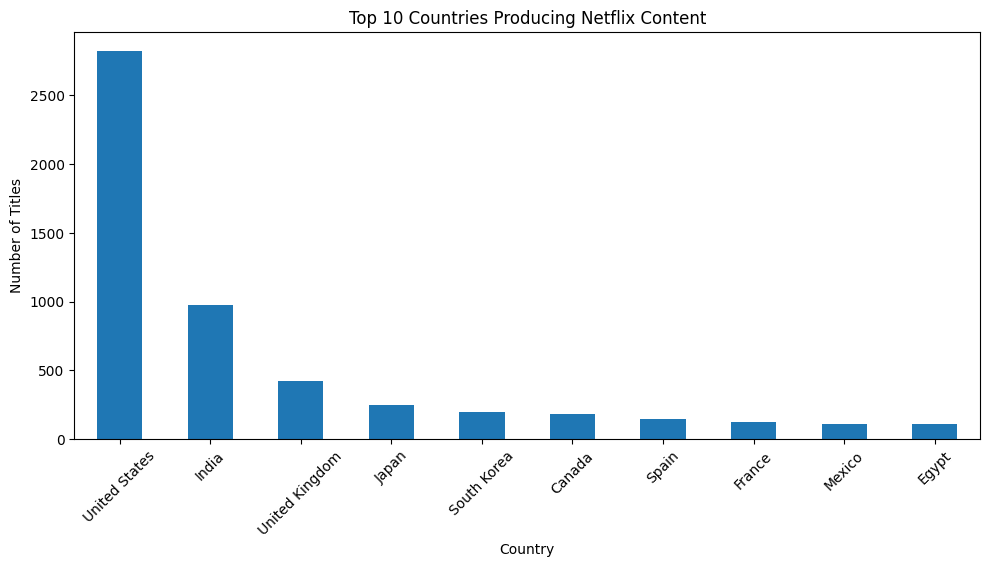

In [36]:
df_filtered = df[df['country'] != 'Unknown']

top_countries = df_filtered['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.savefig('top_countries.png')

plt.xticks(rotation=45)
plt.show()

## Netflix Content Release Trend

This visualization shows how Netflix content production has changed over the years.

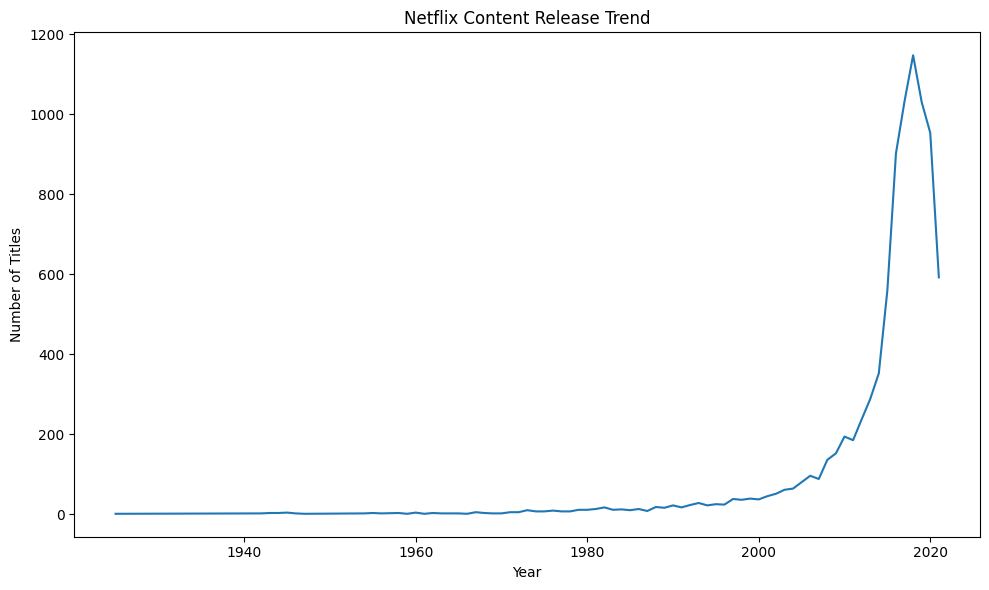

In [37]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(10,6))
year_counts.plot(kind='line')

plt.title('Netflix Content Release Trend')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.savefig('release_trend.png')

plt.show()

## Content Ratings Distribution

This chart shows the distribution of content ratings on Netflix.

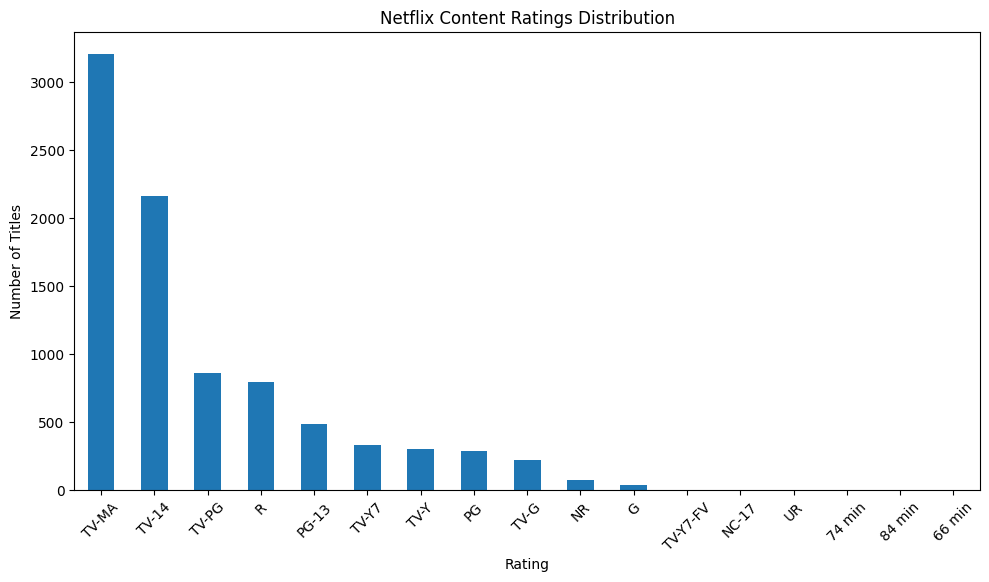

In [38]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10,6))
rating_counts.plot(kind='bar')

plt.title('Netflix Content Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.savefig('ratings_distribution.png')

plt.xticks(rotation=45)

plt.show()

## Movies vs TV Shows Trend Over Time

This analysis compares how the number of movies and TV shows released on Netflix has changed over time.

<Figure size 1000x600 with 0 Axes>

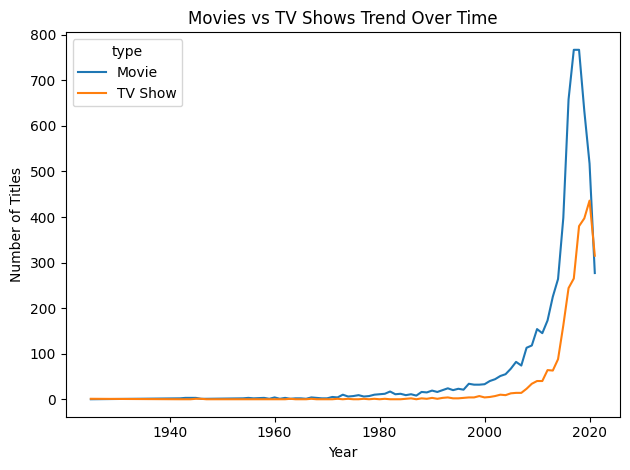

In [39]:
content_trend = df.groupby(['release_year','type']).size().unstack()
content_trend = content_trend.fillna(0)

plt.figure(figsize=(10,6))
content_trend.plot()

plt.title('Movies vs TV Shows Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')

plt.show()

## Key Insights

- Netflix has more Movies than TV Shows.
- The United States produces the highest number of Netflix titles.
- Netflix content production increased significantly after 2015.
- TV-MA is the most common content rating.
- Both Movies and TV Shows have grown rapidly over the last decade.